# Visualizing Emergency Department Length of Stay with PROC BOX

## Executive Summary

A hospital-operations analysis that uses PROC BOXPLOT (aliased as PROC BOX) to compare emergency-department length of stay across three clinical services. Side-by-side schematic box plots show each service's median, quartiles, mean, and long-stay outliers at a glance.

Across 100 simulated encounters, median length of stay rises steadily from **45.65 hours in Medicine** to **50.70 hours in Surgery** to **62.50 hours in Trauma**, and the means follow the same order (46.94, 60.04, 67.48 hours). All three services carry long-stay outliers beyond their upper whiskers — the boarding cases that consume the most bed-hours — but Surgery's are by far the most extreme: three encounters at 118.9, 136.3, and 142.8 hours sit beyond three times the interquartile range and drag Surgery's mean roughly 9 hours above its median. The notebook draws the comparison three ways: a schematic plot, a mean-trend overlay, and a horizontal layout.

## Data Sources

All data is generated inline by the first DATA step (`call streaminit(20260531)`); no external or network input is used.

**`ed_los`** — one row per emergency-department encounter (100 rows)

| Variable | Type | Description |
|----------|------|-------------|
| `PatientID` | Num | Sequential encounter identifier (1-100) |
| `Department` | Char(12) | Admitting service: Medicine, Surgery, Trauma |
| `Severity` | Char(8) | Triage acuity: Routine (~55%), Urgent (~30%), Critical (~15%) |
| `LOS_Hours` | Num | Length of stay in hours; a service- and severity-driven mean plus normal noise, with an occasional long-stay shock (labeled "Length of Stay (hours)") |

The realized mix is Medicine 34 / Surgery 36 / Trauma 30 encounters, and Routine 51 / Urgent 35 / Critical 14 by triage acuity.

# Visualizing Emergency Department Length of Stay with PROC BOX

Length of stay (LOS) is one of the most closely watched operational metrics in a hospital emergency department: it drives bed availability, staffing, patient throughput, and quality scores. Averages alone hide the story — what matters to an operations team is the *spread* of stays, the *outliers* that tie up resources, and how distributions differ across clinical services.

PROC BOX (an alias for PROC BOXPLOT) is purpose-built for exactly this comparison. It draws side-by-side box-and-whisker plots, marking each group's median, quartiles, mean, and extreme observations, so an analyst can read the shape of every service's LOS distribution at a glance.

In this notebook we:

1. Generate a synthetic ED encounter dataset that fits the 100-observation environment.
2. Produce a schematic box plot of LOS by department, with the accompanying statistics table.
3. Overlay a mean-trend line with `BOXCONNECT=MEAN` to make the service gradient explicit.
4. Redraw the same comparison horizontally with `HORIZONTAL`.

## Step 1 — Generate synthetic ED encounter data

We simulate 100 emergency-department encounters. Each patient is assigned to one of three clinical services (Medicine, Surgery, Trauma) and a triage severity (Routine, Urgent, Critical). Length of stay is built from a service-specific baseline, shifted upward for higher-acuity patients, with normally distributed noise. A small fraction of encounters receive an extra long-stay shock to mimic the heavy right tail real ED data always shows (boarding, admissions awaiting an inpatient bed). The fixed seed in `call streaminit` makes the dataset fully reproducible.

In [1]:
options linesize=96;

data ed_los;
   call streaminit(20260531);
   length Department $ 12 Severity $ 8;
   array depts[3] $ 12 _temporary_ ('Medicine' 'Surgery' 'Trauma');
   array sevp[3]  $ 8  _temporary_ ('Routine' 'Urgent' 'Critical');
   do PatientID = 1 to 100;
      d = rand('integer', 1, 3);
      Department = depts[d];

      u = rand('uniform');
      if u < 0.55 then s = 1;
      else if u < 0.85 then s = 2;
      else s = 3;
      Severity = sevp[s];

      base = 24 + 10*d + 14*(s - 1);
      LOS_Hours = base + rand('normal', 0, 7);
      if rand('uniform') < 0.06 then
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      if LOS_Hours < 2 then LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      output;
   end;
   drop d u s base;
   label LOS_Hours = 'Length of Stay (hours)';
run;

NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Sort by the group variable

PROC BOX expects the group (horizontal-axis) variable to be sorted so that observations for each group are contiguous. We sort by `Department` before plotting.

In [2]:
proc sort data=ed_los;
   by Department;
run;

NOTE: PROC SORT data=ed_los

NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Step 3 — Schematic box plot

The core analysis. The `PLOT analysis-var * group-var` syntax requests one box per department. `BOXSTYLE=SCHEMATIC` produces a classic Tukey schematic plot: whiskers extend to the most extreme observations within 1.5 times the interquartile range, and any points beyond that are drawn individually as outliers — ideal for spotting the long-stay cases that strain capacity.

`NOHLABEL` suppresses the redundant horizontal-axis label since the department names are self-explanatory. Alongside the plot, PROC BOXPLOT prints a statistics table giving each department's N, minimum, quartiles, median, maximum, mean, and standard deviation.

                                ED Length of Stay by Department                                 

                                ED Length of Stay by Department

                                     The BOXPLOT Procedure

Schematic Plots for Length of Stay (hours)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Medicine             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Surgery              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------


NOTE: Option TITLE changed to ED Length of Stay by Department.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


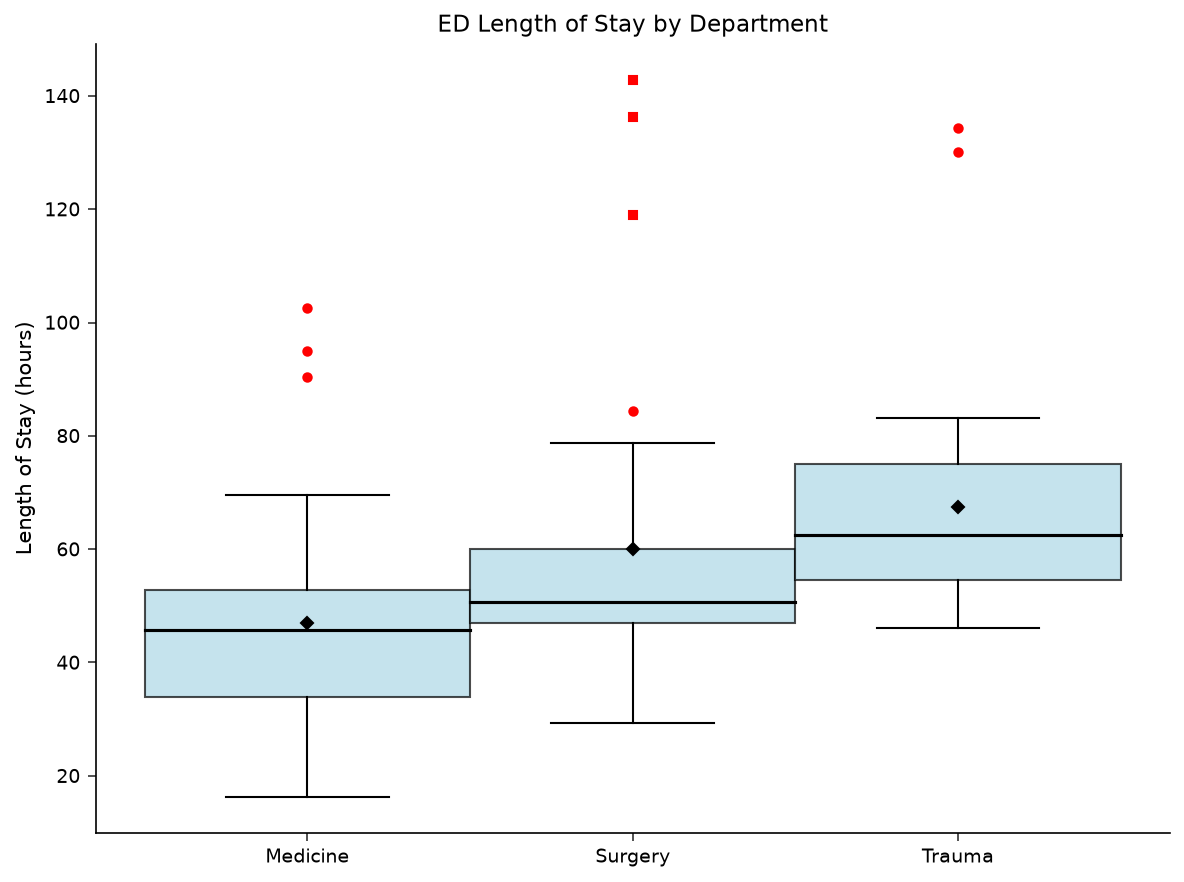

In [3]:
title 'ED Length of Stay by Department';
proc boxplot data=ed_los;
   plot LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
run;

## Step 4 — Overlay a mean-trend line

To make the service-to-service gradient explicit, we add `BOXCONNECT=MEAN`. PROC BOXPLOT then draws a connecting line through the mean of each box (the diamond markers), turning the three separate distributions into a single readable trend. Because the departments are ordered Medicine → Surgery → Trauma, the rising connect-line summarizes the escalation in average length of stay in one stroke — a useful cue for an operations dashboard.

                          ED Length of Stay by Department - Mean Trend                          

                          ED Length of Stay by Department - Mean Trend

                                     The BOXPLOT Procedure

Schematic Plots for Length of Stay (hours)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Medicine             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Surgery              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------


NOTE: Option TITLE changed to ED Length of Stay by Department - Mean Trend.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


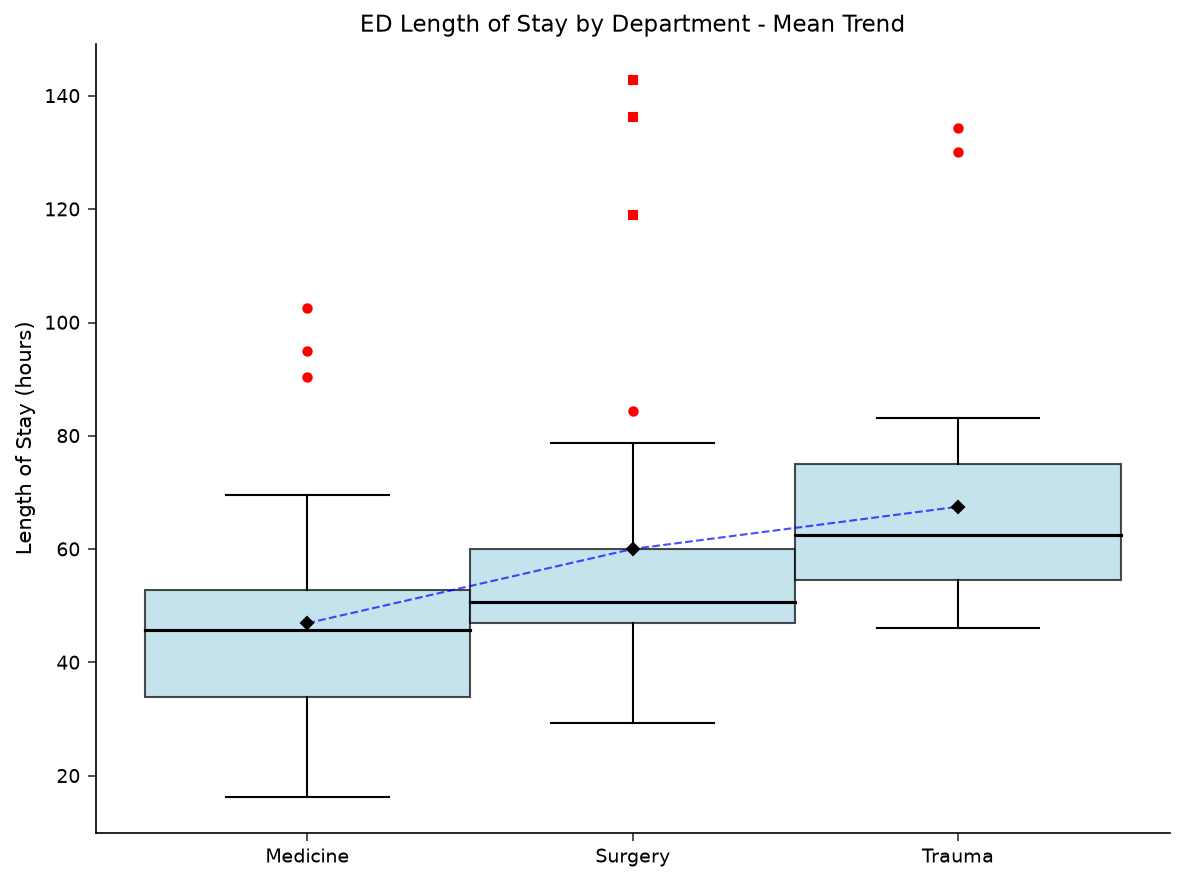

In [4]:
title 'ED Length of Stay by Department - Mean Trend';
proc boxplot data=ed_los;
   plot LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
run;

## Step 5 — Horizontal layout

The same comparison reads naturally on its side. Adding `HORIZONTAL` swaps the axes so the boxes run left-to-right with the response on the x-axis — a layout that scales better when service names are long or numerous, and that many operations dashboards prefer. The statistics are identical to the vertical view; only the orientation changes.

                          ED Length of Stay by Department - Horizontal                          

                          ED Length of Stay by Department - Horizontal

                                     The BOXPLOT Procedure

Schematic Plots for Length of Stay (hours)

Department            N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Medicine             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Surgery              36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Trauma               30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------


NOTE: Option TITLE changed to ED Length of Stay by Department - Horizontal.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


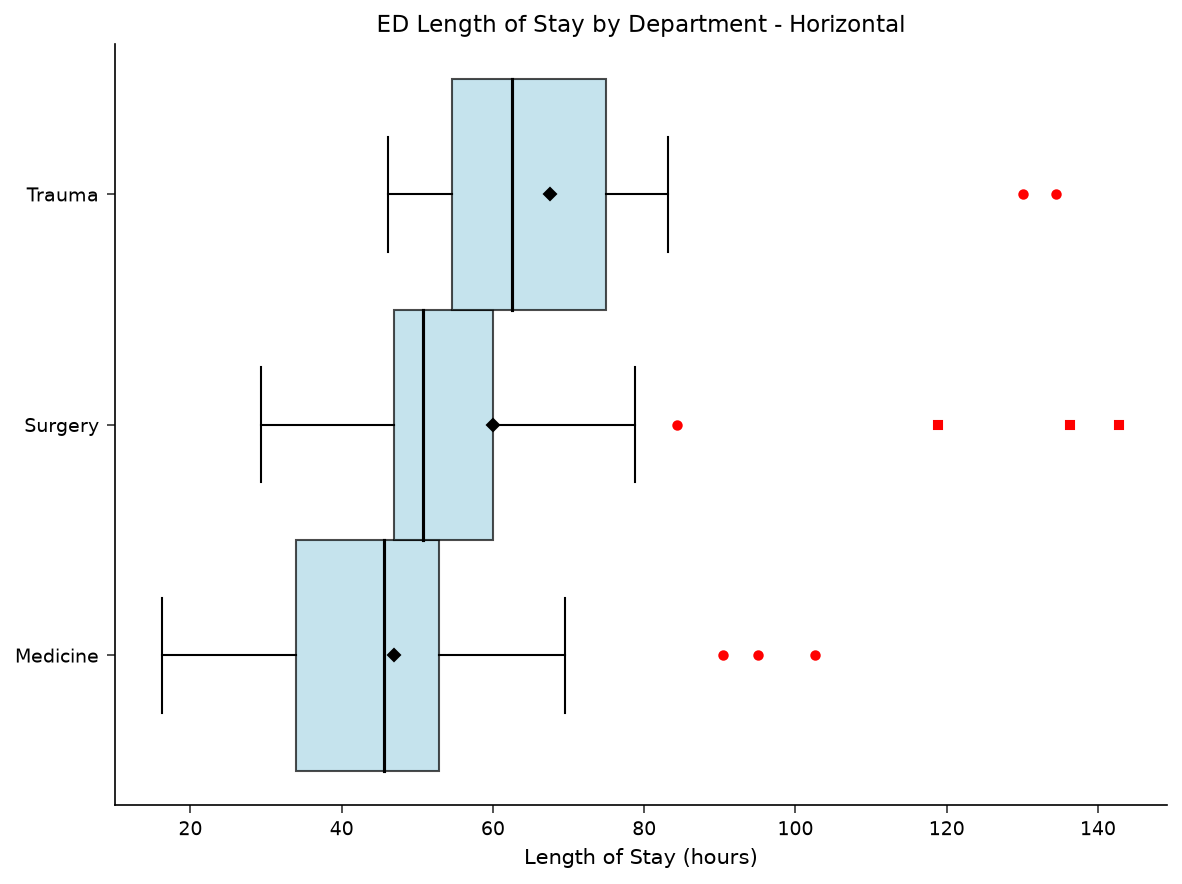

In [5]:
title 'ED Length of Stay by Department - Horizontal';
proc boxplot data=ed_los;
   plot LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
run;

## Interpreting the results

The box plots and the accompanying statistics table translate the raw LOS data into an operationally actionable picture:

- **A clear service gradient.** Median length of stay rises monotonically across the three services: **Medicine 45.65 h → Surgery 50.70 h → Trauma 62.50 h**. The means tell the same story (46.94, 60.04, 67.48 h), and the `BOXCONNECT=MEAN` line in Step 4 draws that escalation as a single rising trend. Trauma patients stay about 44% longer than Medicine patients on average.

- **The mean sits well above the median where boarding bites.** Compare each service's mean to its median: Medicine and Trauma differ by only about 1.3 and 5.0 hours, but **Surgery's mean (60.04 h) runs 9.3 hours above its median (50.70 h)**. That gap is the fingerprint of a heavy right tail — a handful of very long Surgery stays pull the average up while leaving the median, a more robust center, almost unchanged. It is exactly the divergence a box plot is built to expose.

- **Variability is highest for Trauma, not Medicine.** Reading box height (the interquartile range) off the table: Trauma spans Q1 54.53 h to Q3 74.95 h (a 20.4-hour IQR), Medicine spans 33.90 h to 52.80 h (18.9 h), and Surgery is the tightest at 46.90 h to 60.02 h (13.1 h). So the typical Surgery stay is the most predictable in its middle half, even though Surgery owns the most extreme outliers — a distinction averages alone would hide.

- **Outliers flag the boarding cases in every service.** The schematic whiskers stop at 1.5 × IQR, and all three services post points beyond them: Medicine shows three (90.4, 95.0, 102.6 h), Trauma two (130.1, 134.4 h), and Surgery four. Surgery's are the worst — its three highest (**118.9, 136.3, 142.8 h**) lie beyond *three* times the IQR, so PROC BOXPLOT draws them as squares (far outliers) rather than circles. These are the boarding cases that consume disproportionate bed-hours.

- **Range tells the capacity-planning story.** Observed stays span 16.3–102.6 h in Medicine, 29.3–142.8 h in Surgery, and 46.1–134.4 h in Trauma. Trauma still never produces a short stay — its minimum, 46.1 h, edges past Medicine's median (45.65 h) — which is what an operations team would expect from the most resource-intensive service.

Together these views give an ED leadership team a defensible, distribution-aware basis for staffing and capacity planning — far more informative than comparing departmental average LOS alone.